In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import os
import math
import warnings
import numpy as np
warnings.filterwarnings('ignore')

In [2]:
root = '/home/shamini/data2/projects/chiba_pathomics/'
data_dir = root+'data/'
out = root+'out_feb2025_xenium/'
os.makedirs(out, exist_ok=True)

xenium_dir = root+'data/xenium_redownload/Xenium Output Glioma TMA/'

In [3]:
'''
Tissue microarray core metadata
'''

meta = pd.read_csv(data_dir+'tma_meta.csv', delimiter=',')
meta

,x_tma,y_tma,Samples,Region,Type,Patient
0,x1,y1,Oligo1- Edge,Edge,Oligo,Oligo1
1,x1,y2,Oligo1- Core,Core,Oligo,Oligo1
2,x1,y3,Oligo2- Edge,Edge,Oligo,Oligo2
3,x1,y4,Oligo2- Core,Core,Oligo,Oligo2
4,x1,y5,Oligo3- Edge,Edge,Oligo,Oligo3
5,x1,y6,Oligo3 - Core,Core,Oligo,Oligo3
6,x1,y7,Oligo4- Edge,Edge,Oligo,Oligo4
7,x1,y8,Oligo4- Core,Core,Oligo,Oligo4
8,x1,y9,Oligo5- Edge,Edge,Oligo,Oligo5
9,x1,y10,Oligo5- Core,Core,Oligo,Oligo5


In [4]:
### paths
features_filepath = xenium_dir+'cell_feature_matrix.h5'
cells_filename = out+'script01b_coord_warped_dapi_he/cells_warped.parquet'
transcripts_filename = out+'script01b_coord_warped_dapi_he/transcripts_warped.parquet'

In [5]:
### import cell matrix data
df_cell = pd.read_parquet(cells_filename)

adata = sc.read_10x_h5(features_filepath)
df_cell.set_index(adata.obs.index, inplace=True)
adata.obs = df_cell.copy()

In [6]:
df_cell

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,x_location_px,y_location_px
aaaabdnh-1,aaaabdnh-1,837.657532,7449.898926,202,0,0,0,0,202,431.513141,45.788439,4899.050299,6757.457067
aaabdcme-1,aaabdcme-1,851.395752,7461.416504,273,0,0,0,0,273,439.596110,48.768752,4892.067761,6751.647582
aaabheaf-1,aaabheaf-1,826.551575,7473.680176,387,0,0,0,0,387,591.321115,61.457658,4904.486382,6745.445366
aaabnbei-1,aaabnbei-1,849.778870,7480.069336,229,0,0,0,0,229,441.041110,48.362346,4892.807028,6742.255535
aaacggkb-1,aaacggkb-1,843.591736,7497.011230,183,0,0,0,0,183,378.770639,23.165157,4895.863472,6733.740479
...,...,...,...,...,...,...,...,...,...,...,...,...,...
oipjbjkd-1,oipjbjkd-1,8266.048828,16107.699219,107,0,0,0,1,108,113.071254,26.687345,1169.304167,2435.834715
oipjckni-1,oipjckni-1,8278.181641,16109.211914,117,0,0,1,0,118,156.737349,36.802345,1163.245793,2435.102261
oipkbibe-1,oipkbibe-1,8294.672852,16108.346680,123,0,0,0,0,123,146.532037,30.525626,1155.016410,2435.563288
oipkcbii-1,oipkcbii-1,8364.084961,16104.795898,136,0,0,0,0,136,147.660943,36.170158,1120.365197,2437.454234


In [7]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)


In [8]:
### sum all control probe counts

columns = [col for col in adata.obs.columns if 'control' in col]

col_df = adata.obs[columns]
col_df = col_df.mean(axis=1)
col_df.max()

np.float64(3.0)

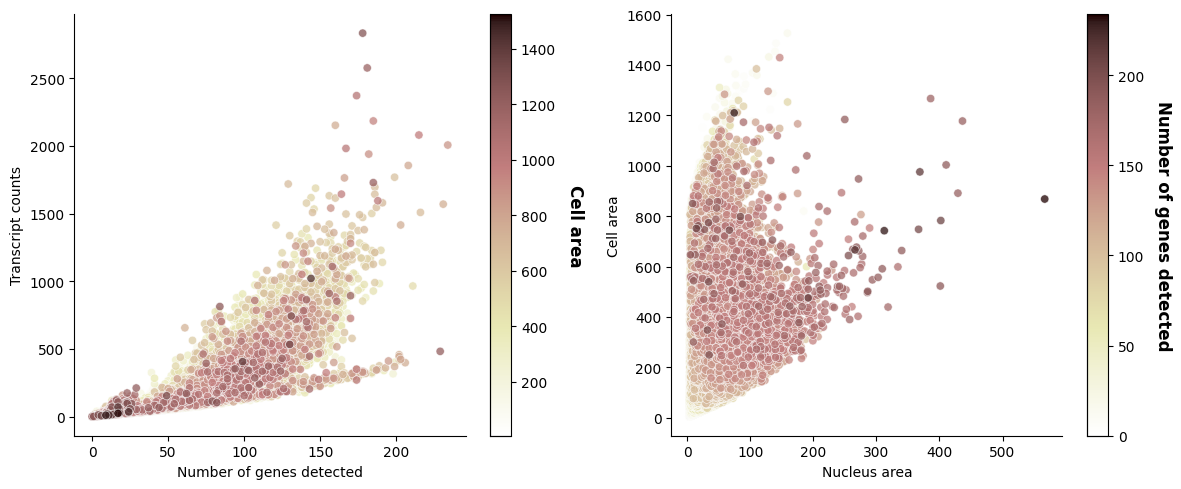

In [9]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib import colormaps as cm
### get color map


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cmap = cm.get_cmap('pink_r')

sorted_index = adata.obs.sort_values('cell_area', ascending=True).index
adata.obs = adata.obs.loc[sorted_index]
sns.scatterplot(data=adata.obs, x='n_genes_by_counts', y='transcript_counts', hue='cell_area', alpha=0.75, ax=axes[0], palette='pink_r')
axes[0].legend_.remove()
axes[0].xaxis.set_label_text('Number of genes detected')
axes[0].yaxis.set_label_text('Transcript counts')

norm = Normalize(vmin=adata.obs['cell_area'].min(), vmax=adata.obs['cell_area'].max())
cm.colorbar = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes[0])
cm.colorbar.set_label('Cell area', rotation=270, labelpad=20, fontsize=12, fontweight='bold')


sorted_index = adata.obs.sort_values('n_genes_by_counts', ascending=True).index
adata.obs = adata.obs.loc[sorted_index]
sns.scatterplot(data=adata.obs, x='nucleus_area', y='cell_area', hue='n_genes_by_counts', alpha=0.75, ax=axes[1], palette='pink_r')
axes[1].legend_.remove()
axes[1].xaxis.set_label_text('Nucleus area')
axes[1].yaxis.set_label_text('Cell area')



norm = Normalize(vmin=adata.obs['n_genes_by_counts'].min(), vmax=adata.obs['n_genes_by_counts'].max())
cm.colorbar = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes[1])
cm.colorbar.set_label('Number of genes detected', rotation=270, labelpad=20, fontsize=12, fontweight='bold')


plt.tight_layout()
sns.despine()

145.0
61.0


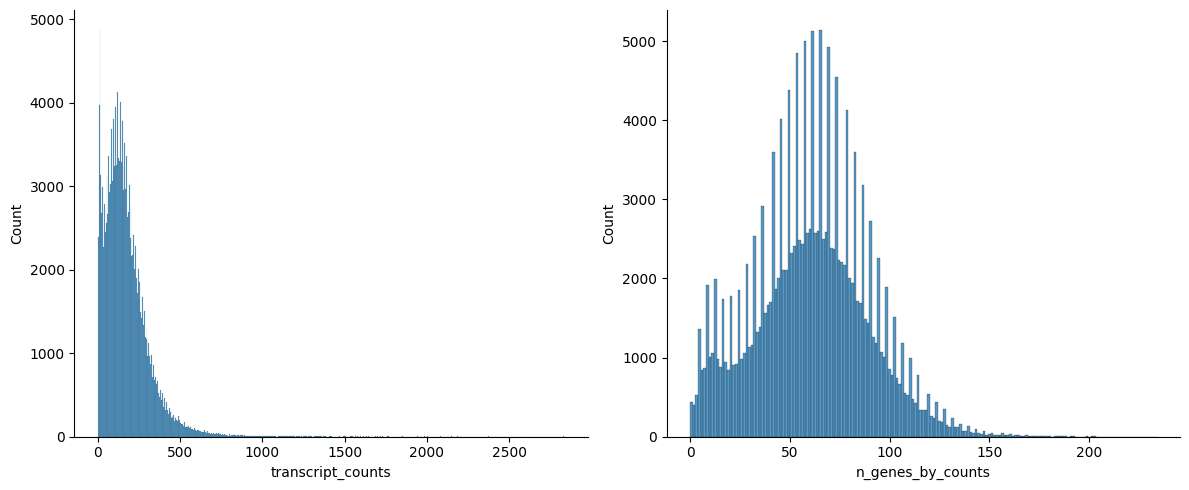

In [10]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib import colormaps as cm
### get color map


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=adata.obs, x='transcript_counts', ax=axes[0])
sns.histplot(data=adata.obs, x='n_genes_by_counts', ax=axes[1])

print(adata.obs['transcript_counts'].median())
print(adata.obs['n_genes_by_counts'].median())

plt.tight_layout()
sns.despine()

<Axes: xlabel='x_location_px', ylabel='y_location_px'>

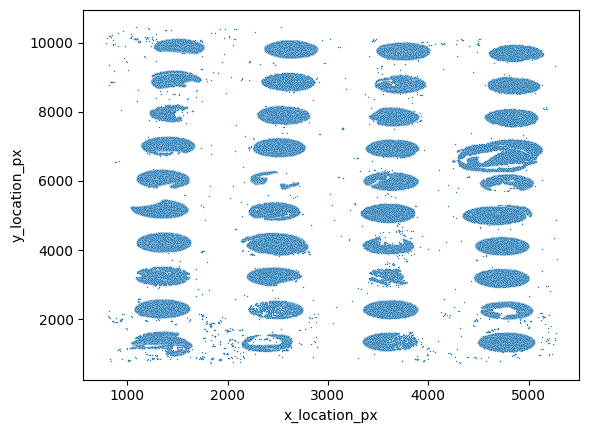

In [11]:
sns.scatterplot(x='x_location_px', y='y_location_px', data=adata.obs, s=1)


<Axes: ylabel='Frequency'>

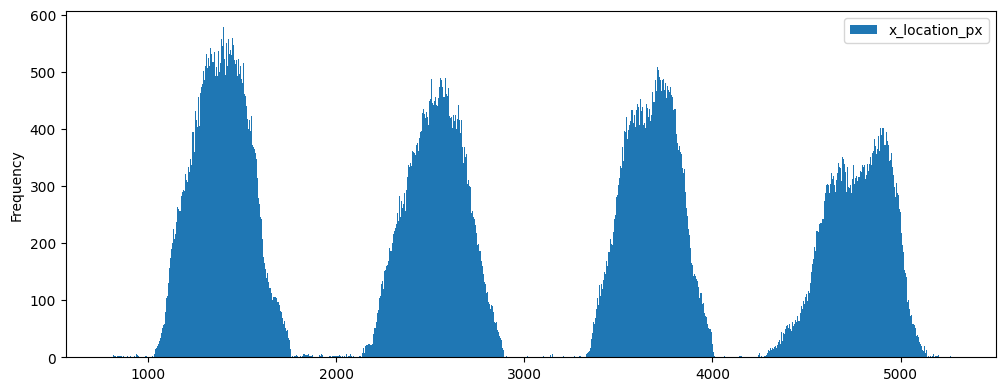

In [12]:
adata.obs.plot.hist(y='x_location_px', bins=1000, figsize=(12,4.5))


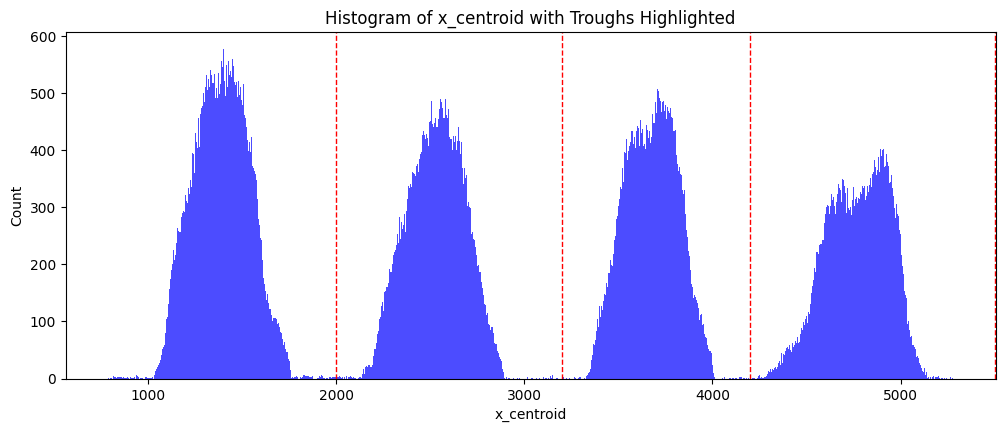

In [13]:
hist, bin_edges = np.histogram(adata.obs['x_location_px'], bins=1000)

# Find the troughs
#troughs = [900,2000, 3000, 4100]
troughs = [2000, 3200, 4200, 5500
             ]
#troughs = [int(trough/.2125) for trough in troughs]
x_centroid = adata.obs['x_location_px']
#x_centroid = x_centroid.values/0.2125

# Plot the histogram
plt.figure(figsize=(12, 4.5))
plt.hist(x_centroid, bins=1000, color='blue', alpha=0.7)

# Add vertical lines at troughs
for trough in troughs:
    plt.axvline(x=trough, color='red', linestyle='--', linewidth=1)

plt.title('Histogram of x_centroid with Troughs Highlighted')
plt.xlabel('x_centroid')
plt.ylabel('Count')
plt.show()

In [14]:
troughs

[2000, 3200, 4200, 5500]

In [15]:
### split anndata object
adatas = []
initial = 0

#adata.obs['x_centroid_px'] = adata.obs['x_centroid']/0.2125

n=4
for x, trough in enumerate(troughs):
    #ad = adata[(adata.obs['x_location_px']<trough) & (adata.obs['x_location_px']>initial)].copy()
    obs = adata.obs[(adata.obs['x_location_px']<trough) & (adata.obs['x_location_px']>initial)]
    #ad = adata[cell_ids].copy()
    obs['x_tma'] = 'x'+str(n-x)
    #ad.obs['x_location_px'] = ad.obs['x_location_px'] - initial
    adatas.append(obs)
    initial = trough


In [16]:
for ad in adatas:
    print(ad.shape)

(50291, 15)
(43125, 15)
(42394, 15)
(38451, 15)


<Axes: xlabel='x_location_px', ylabel='y_location_px'>

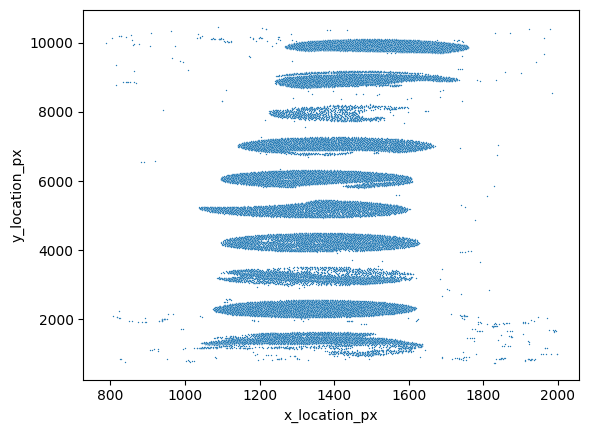

In [17]:
n=0
sns.scatterplot(x=adatas[n]['x_location_px'], y=adatas[n]['y_location_px'], s=1)


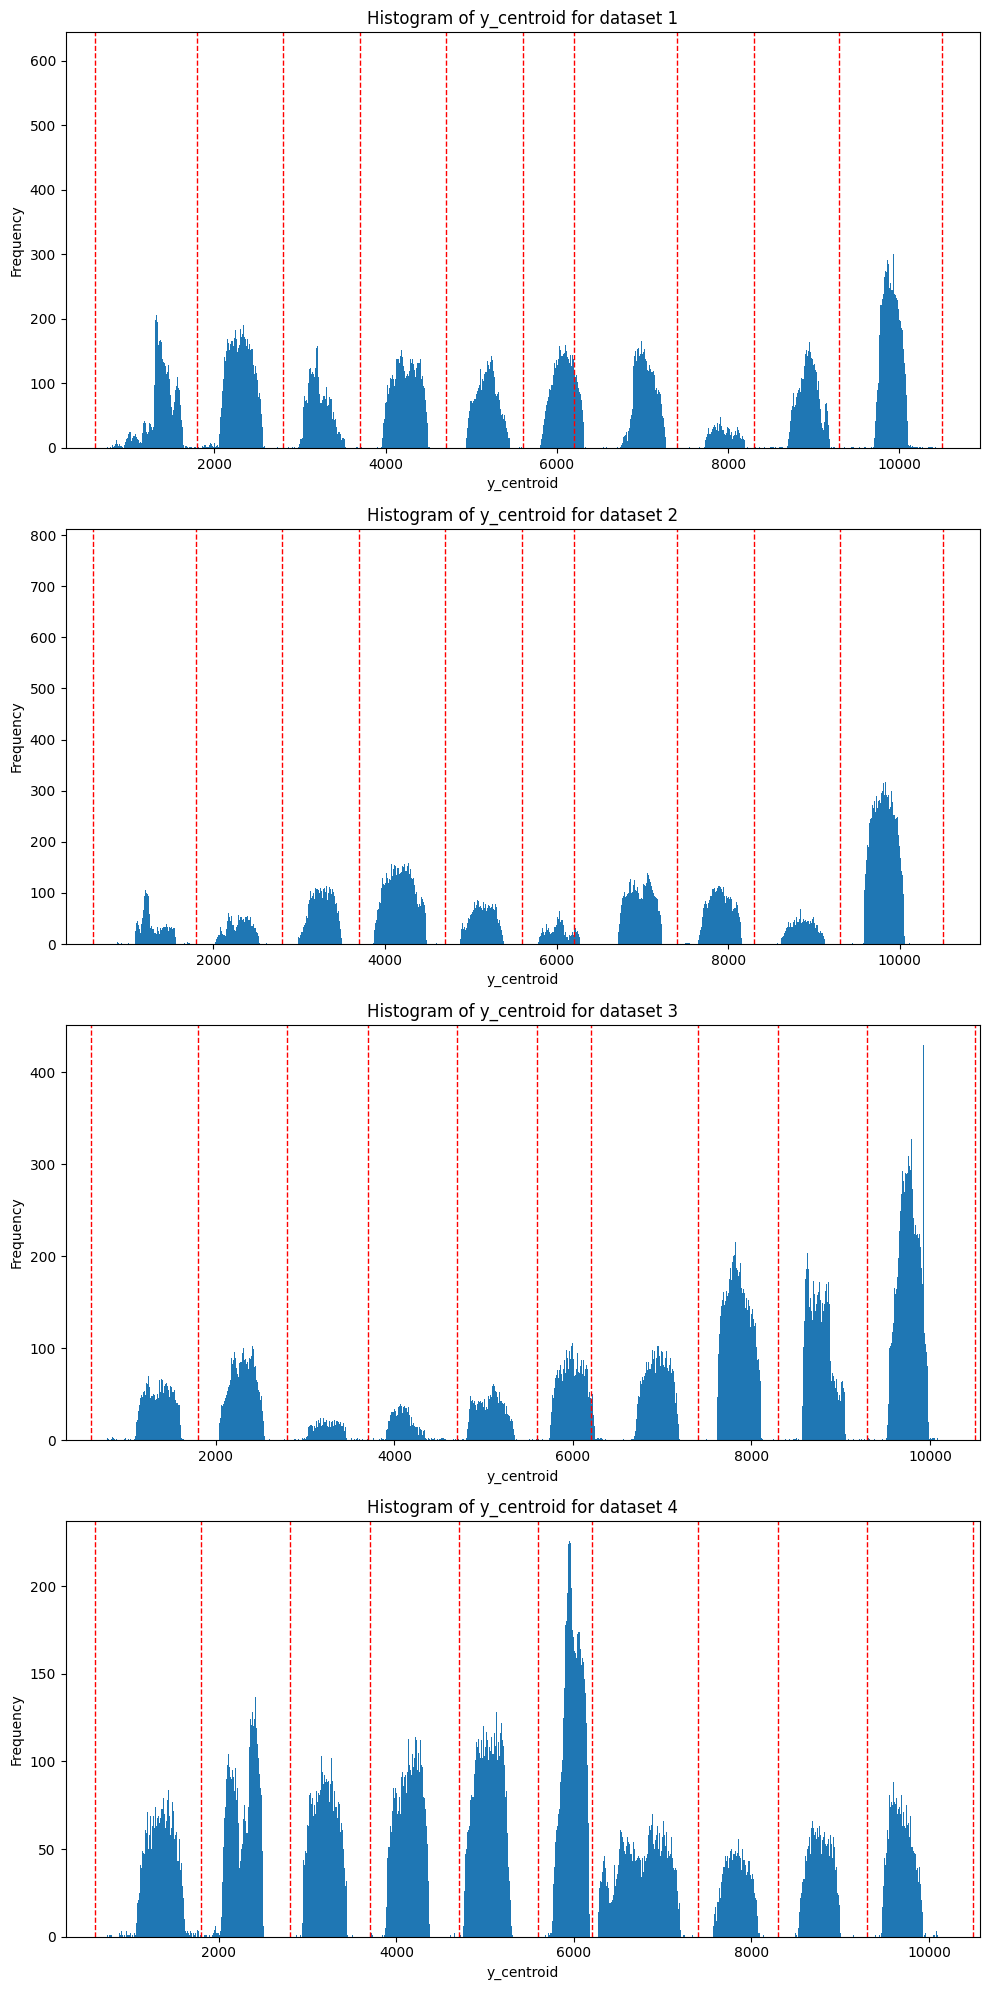

In [18]:
import matplotlib.pyplot as plt

# Assuming 'adatas' is a list of data structures similar to pandas DataFrames
# and each has an 'obs' DataFrame with a 'y_centroid' column.

troughs_y1 = [#750, 
              600, 1800, 2800, 3700, 4700, 5600, 6200, 7400, 8300, 9300, 10500]
troughs_y2 = [#500, 
              600, 1800, 2800, 3700, 4700, 5600, 6400, 7400, 8300, 9300, 10500]
#troughs = [int(trough/.2125) for trough in troughs]

fig, axs = plt.subplots(4, 1, figsize=(10, 20))  # You can specify figsize to control the size of the figure
#y_centroid = y_centroid.values/0.2125

for a, adata in enumerate(adatas):
    y_centroid = adata['y_location_px']
    axs[a].hist(y_centroid, bins=1000)
    # Add vertical lines at troughs
    for trough in troughs_y1:
        axs[a].axvline(x=trough, color='red', linestyle='--', linewidth=1)
    axs[a].set_title(f"Histogram of y_centroid for dataset {a+1}")
    axs[a].set_xlabel('y_centroid')
    axs[a].set_ylabel('Frequency')

plt.tight_layout()  # Adjusts subplot params so that subplots fit into the figure area.
plt.show()

In [ ]:
meta

In [20]:
### import cell matrix data
df_cell = pd.read_parquet(cells_filename)

adata_orig = sc.read_10x_h5(features_filepath)
df_cell.set_index(adata_orig.obs.index, inplace=True)
adata_orig.obs = df_cell.copy()

In [21]:
### split anndata object
adatas_tmas = []
for i in range(len(adatas)):
    initial = 600
    if i==3:
        troughs = [#750, 
            1800, 2800, 3700, 4700, 5600, 6200, 7400, 8300, 9300, 10500]
    else:
        troughs = [#750, 
            1800, 2800, 3700, 4700, 5600, 6400, 7400, 8300, 9300, 10500]

    adata=adatas[i]
    #adata.obs['y_centroid_px'] = adata.obs['y_centroid']/0.2125
    #troughs = [int(trough/.2125) for trough in troughs]
    adata.sort_index(inplace=True)

    
    for y, trough in enumerate(troughs):
        #ad = adata[(adata.obs['y_location_px']<trough) & (adata.obs['y_location_px']>initial)].copy()

        cell_ids = adata[(adata['y_location_px']<trough) & (adata['y_location_px']>initial)].index
        ad = adata_orig[adata_orig.obs['cell_id'].isin(cell_ids)].copy()
        ad.obs['y_tma'] = 'y'+str(y+1)
        ad.obs['x_tma'] = adata['x_tma'].unique()[0]
        #ad.obs['y_location_px'] = ad.obs['y_location_px'] - initial
        adatas_tmas.append(ad)
        initial = trough
        print(ad.obs['y_tma'].unique())
    

['y1']
['y2']
['y3']
['y4']
['y5']
['y6']
['y7']
['y8']
['y9']
['y10']
['y1']
['y2']
['y3']
['y4']
['y5']
['y6']
['y7']
['y8']
['y9']
['y10']
['y1']
['y2']
['y3']
['y4']
['y5']
['y6']
['y7']
['y8']
['y9']
['y10']
['y1']
['y2']
['y3']
['y4']
['y5']
['y6']
['y7']
['y8']
['y9']
['y10']


In [23]:
adatas_tmas[0].obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,x_location_px,y_location_px,y_tma,x_tma
abeobhpj-1,abeobhpj-1,6607.934570,17656.435547,23,0,0,9,0,32,555.918614,16.572344,1995.315029,1657.805059,y1,x4
abnfdjbm-1,abnfdjbm-1,7829.565430,17712.824219,305,0,0,0,0,305,375.022670,33.415626,1384.552346,1632.344348,y1,x4
abngebjo-1,abngebjo-1,7765.945312,17725.580078,237,0,0,0,0,237,419.185484,31.790001,1416.269150,1626.050831,y1,x4
abngjnpc-1,abngjnpc-1,7745.696777,17726.042969,220,0,0,0,0,220,424.288140,35.899220,1426.390740,1625.846919,y1,x4
abnglkmp-1,abnglkmp-1,7778.800293,17714.396484,138,0,0,0,0,138,332.756418,26.100313,1409.895949,1631.523149,y1,x4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
eiakmjle-1,eiakmjle-1,8697.642578,19252.179688,1,0,0,0,0,1,858.646125,7.044375,951.143482,862.667633,y1,x4
eiakogld-1,eiakogld-1,8949.593750,19271.644531,69,0,0,15,0,84,664.248462,27.861407,825.289191,853.424798,y1,x4
eialhbae-1,eialhbae-1,8946.273438,19289.333984,35,0,0,12,0,47,494.867362,11.379375,826.913649,844.584090,y1,x4
ejfhfbcc-1,ejfhfbcc-1,6940.251465,19460.531250,35,0,0,5,0,40,565.852989,19.913907,1828.339116,755.277701,y1,x4


In [37]:
medians_gene = []
medians_counts = []

for adata in adatas_tmas:
    ngenes = adata.X.sum(axis=1)
    ncounts = adata.obs['total_counts']
    medians_gene.append(np.median(ngenes))
    medians_counts.append(np.median(ncounts))


In [41]:
### maximum counts from median_counts
np.max(medians_counts), np.min(medians_counts), np.mean(medians_counts), np.std(medians_counts)

(np.float64(312.0),
 np.float64(11.5),
 np.float64(158.475),
 np.float64(63.34083891929439))

In [ ]:
fig, axs = plt.subplots(4, 10, figsize=(9, 4))  # You can specify figsize to control the size of the figure
axs = axs.flatten()

for i, ad in enumerate(adatas_tmas):
    sns.scatterplot(x='x_location_px', y='y_location_px', data=ad.obs, s=1, ax=axs[i])
    axs[i].set_title(f"{ad.obs['x_tma'][0]}_{ad.obs['y_tma'][0]}", fontsize=6)
    
    for ax in axs:
        ax.axis('off')

In [ ]:
### Create lists and extract data
# Now pull the h5 files from 10x and start analyzing the files 
adatas_new = []
for i, adata in enumerate(adatas_tmas):
	#adata.uns['sample'] =  df.split('/')[-2].split('__')[-3]
    
    adata.obsm['spatial'] = adata.obs[['x_centroid', 'y_centroid']].copy().to_numpy()
    
    core_id = meta[meta['x_tma'].isin(adata.obs['x_tma']) & meta['y_tma'].isin(adata.obs['y_tma'])]['Samples'].values[0]
    core_id = core_id.strip().replace('- ', '_').replace(' -', '_').replace('-  ', '_').replace(' - ', '_').replace(' ', '_')

    adata.uns['core_id'] = core_id
    
    #obs_old = adata.obs
    meta_subset = meta[meta['x_tma'].isin(adata.obs['x_tma']) & meta['y_tma'].isin(adata.obs['y_tma'])]
    #meta_subset = pd.concat([meta_subset]*len(obs_old), ignore_index=True)
    #meta_subset.index = obs_old.index
    #obs_new = pd.concat([obs_old, meta_subset], axis=1)

    for col in meta_subset.columns:
        print(meta_subset[col].values[0])
        adata.obs[col] = meta_subset[col].values[0]

    #adata.obs = obs_new
    sc.pp.calculate_qc_metrics(adata, percent_top=(5,10,15,20) ,inplace=True) ### calculate qc metrics from scater package

    sc.pp.filter_cells(adata, min_counts=9)
    sc.pp.filter_genes(ad, min_cells=9)

	### copy counts to layers
    adata.raw = adata.copy()
    adata.layers["counts"] = adata.X.copy()

    ### normalized by median counts
    sc.pp.normalize_total(adata, inplace=True)
    adata.layers["norm"] = adata.X.copy()

	### transformed using log1p
    sc.pp.log1p(adata)
    adata.layers["log1p"] = adata.X.copy()
    adata.layers['scaled'] = sc.pp.scale(adata, copy=True).X
    
#    	cprobes = (adata.obs["control_probe_counts"].sum()/adata.obs["total_counts"].sum())*100
#    	cwords = (adata.obs["control_codeword_counts"].sum()/adata.obs["total_counts"].sum())*100

#	print(f"Negative DNA probe count % = {cprobes:9f}")
#	print(f"Negative DNA codeword count % = {cwords:9f}")

    ### Perform normalization, transformation, and scaling on individual anndata objects

	#for adata in adatas:
    sc.pp.pca(adata, n_comps=21, svd_solver="arpack")
    sc.pp.neighbors(adata, n_pcs=21, n_neighbors=15)
    sc.tl.umap(adata, n_components=9)
    sc.tl.leiden(adata, resolution=1.2)
    
    adatas_new.append(adata)

In [ ]:
out_old = '/home/shamini/data2/projects/chiba_pathomics/out_nov2024/'
adatas_first = [sc.read_h5ad(f'{out_old}script03a_adatas/{f}') for f in os.listdir(os.path.join(out_old, 'script03a_adatas'))]

In [ ]:
print(f'original adata core: {adatas_first[0].uns["core_id"]}, new adata core: {adatas_new[0].uns["core_id"]}')

In [ ]:
print(f'original adata core: {adatas_first[0].raw.X[0:3, 0:3].todense()}, \n new adata core: {adatas_new[0].raw.X[0:3, 0:3].todense()}')

In [ ]:
n=25

adata_first = [adata for adata in adatas_first if adata.uns['core_id'] == adatas_new[n].uns['core_id']][0]
ad1 = adatas_new[n]

In [ ]:
ad1.shape, adata_first.shape

In [ ]:

print(f'original adata core: {adata_first.uns["core_id"]}, new adata core: {ad1.uns["core_id"]}')

#common_cells = ad1.obs_names.intersection(adata_first.obs_names)
#ad1 = ad1[ad1.obs_names.isin(common_cells)]
#adata_first = adata_first[adata_first.obs_names.isin(common_cells)]

In [ ]:
ad1.obs_names

In [ ]:
adata_first.obs_names

In [ ]:
ad1.X[0:3, 0:3].todense(), adata_first.X[0:3, 0:3].todense()

In [ ]:
### split anndata object

geom = pd.read_parquet(out+'script01b_coord_warped_dapi_he/cell_boundaries_warped.parquet')
geom.head()

In [ ]:
random_cells = geom.cell_id.sample(3000)

geom_subset = geom[geom.cell_id.isin(random_cells)] 

grouped = geom_subset.groupby('cell_id')

for name, group in grouped:
    plt.plot(group.vertex_x_px, group.vertex_y_px, marker='o', linestyle='', ms=1)
plt.gca().autoscale()
plt.show()

In [ ]:
### split anndata object
xe_polygons_cropped_out_path = os.path.join(out, 'script01a_xe_polygons_cropped')
os.makedirs(xe_polygons_cropped_out_path, exist_ok=True)

initial_x = 0
troughs_x = [2000, 3200, 4200, 5500
             ]
#troughs_x =[int(x/0.2125) for x in troughs_x]

n=4
for x, trough_x in enumerate(troughs_x):
    initial_y = 600
    if x==3:
        troughs_y = [#750, 
            1800, 2800, 3700, 4700, 5600, 6400, 7400, 8300, 9300, 10500]
    else:
        troughs_y = [#750, 
            1800, 2800, 3700, 4700, 5600, 6200, 7400, 8300, 9300, 10500]

      
    for y, trough_y in enumerate(troughs_y):
#        image = np.zeros((trough_x-initial_x, trough_y-initial_y))
        geom_core = geom[(geom['vertex_x_px']<trough_x) & (geom['vertex_x_px']>initial_x) & (geom['vertex_y_px']<trough_y) & (geom['vertex_y_px']>initial_y)]        
        #glycan_core = glycans[(glycans['x_warped']>trough_x) & (glycans['x_warped']<initial_x) & (glycans['y_warped']<trough_y) & (glycans['y_warped']>initial_y)]
        #peptide_core = peptides[(peptides['x_warped']>trough_x) & (peptides['x_warped']<initial_x) & (peptides['y_warped']<trough_y) & (peptides['y_warped']>initial_y)]
        #met_core = mets[(mets['x_warped']>trough_x) & (mets['x_warped']<initial_x) & (mets['y_warped']<trough_y) & (mets['y_warped']>initial_y)]
        
        #geom_core['vertex_x_px'] = geom_core['vertex_x_px'] - trough_x
        #geom_core['vertex_y_px'] = geom_core['vertex_y_px'] - initial_y
        
        #glycan_core['x_warped'] = glycan_core['x_warped'] - trough_x
        #glycan_core['y_warped'] = glycan_core['y_warped'] - initial_y
        
        #peptide_core['x_warped'] = peptide_core['x_warped'] - trough_x
        #peptide_core['y_warped'] = peptide_core['y_warped'] - initial_y
        
        #met_core['x_warped'] = met_core['x_warped'] - trough_x
        #met_core['y_warped'] = met_core['y_warped'] - initial_y
        
        initial_y = trough_y
        core_id = meta.loc[(meta['x_tma'] == 'x'+str(n-x)) & (meta['y_tma'] == 'y'+str(y+1)), 'Samples'].values[0]
        core_id = core_id.strip().replace('- ', '_').replace(' -', '_').replace('-  ', '_').replace(' - ', '_').replace(' ', '_')

        geom_core.to_parquet(os.path.join(xe_polygons_cropped_out_path, f'polygons_x{n-x}_y{y+1}_{core_id}.parquet'))    
        #glycan_core.to_parquet(os.path.join(polygons_msi_cropped_out_path, f'glycans_x{x+1}_y{y+1}_{core_id}.parquet'))
        #peptide_core.to_parquet(os.path.join(polygons_msi_cropped_out_path, f'peptides_x{x+1}_y{y+1}_{core_id}.parquet'))
        #met_core.to_parquet(os.path.join(polygons_msi_cropped_out_path, f'mets_x{x+1}_y{y+1}_{core_id}.parquet'))
    initial_x = int(trough_x)

In [ ]:
### the same QCs but overlapping the cores

fig, axes = plt.subplots(1, 2, figsize=(12, 5))



for adata in adatas_new:
    sorted_index = adata.obs.sort_values('cell_area', ascending=True).index
    adata.obs = adata.obs.loc[sorted_index]
    sns.scatterplot(data=adata.obs, x='n_genes_by_counts', y='transcript_counts', alpha=0.75, ax=axes[0], s=3)
    #axes[0].legend_.remove()
    axes[0].xaxis.set_label_text('Number of genes detected')
    axes[0].yaxis.set_label_text('Transcript counts')



    sorted_index = adata.obs.sort_values('n_genes_by_counts', ascending=True).index
    adata.obs = adata.obs.loc[sorted_index]
    sns.scatterplot(data=adata.obs, x='nucleus_area', y='cell_area', alpha=0.75, ax=axes[1], s=3)
    #axes[1].legend_.remove()
    axes[1].xaxis.set_label_text('Nucleus area')
    axes[1].yaxis.set_label_text('Cell area')

sns.despine()

In [ ]:
### the same QCs but overlapping the cores

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for adata in adatas_new:
    sns.histplot(data=adata.obs, x='transcript_counts', ax=axes[0])

    sns.histplot(data=adata.obs, x='n_genes_by_counts', ax=axes[1])
sns.despine()

In [ ]:
### save each individual core adata as separate objects
os.makedirs(os.path.join(out, 'script01c_adatas'), exist_ok='True')
adatas_path = out+'script01c_adatas/'

for adata in adatas_new:
    core_id = str(adata.obs['Samples'][0])
    core_id = core_id.strip().replace('- ', '_').replace(' -', '_').replace('-  ', '_').replace(' - ', '_').replace(' ', '_')

    print(core_id)
    adata.write_h5ad(os.path.join(adatas_path, 'adata_'+core_id+'.h5ad'))